In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import time

In [2]:
# Constants
G = 9.81  # gravity
RHO = 1.225  # air density at sea level

# Vehicle Parameters: small UAS, NACA 4412
M = 1.5  # mass (kg)
S = 0.1  # wing area (m^2)
CD = 0.025
CL_MIN = 0.1
CL_MAX = 1.5
N_CL = 10
CL_DISCRETE = np.linspace(CL_MIN, CL_MAX, N_CL)
V_STALL = 14.0
V_MAX = 100.0

In [3]:
# Sceario Parameters
Z_SW = 0.0
H_SW = 200.0
V_SW = 22.0
GAM_SW = np.radians(-5.0)

Z_GOAL = 2500.0
H_GOAL = 0.0

# Grid Resolution
DZ = 50.0
DH = 5.0
DV = 1.0
DGAM = np.radians(2.0)

# Grid Axes
Z_GRID = np.arange(Z_SW, Z_GOAL + DZ, DZ)
H_GRID = np.arange(H_GOAL, H_SW + DH, DH)
V_GRID = np.arange(V_STALL, V_MAX+DV, DV)
GAM_GRID = np.arange(np.radians(-90.0), np.radians(0.0) + DGAM, DGAM)

NZ, NH, NV, NG = len(Z_GRID), len(H_GRID), len(V_GRID), len(GAM_GRID)

# Integration Timestep
DT = 1.0

In [4]:
def eom(v, gamma, CL):
    L = 0.5*RHO*v**2*S*CL
    D = 0.5*RHO*v**2*S*CD

    dz = v*np.cos(gamma)
    dh = v*np.sin(gamma)
    dv = -G*np.sin(gamma) - D/M
    dgam = L/(M*v) - G*np.cos(gamma)/v
    return dz, dh, dv, dgam

def rk4_forward(z, h, v, gamma, CL, dt):
    # Single RK4 step forward in time
    def f(v_, g_):
        return eom(v_, g_, CL)
    
    k1 = f(v, gamma)
    k1z, k1h, k1v, k1g = k1[0], k1[1], k1[2], k1[3]

    v2 = v + k1v*dt/2
    g2 = gamma + k1g*dt/2
    # z2 = z + k1z*dt/2
    # h2 = h + k1h*dt/2
    k2 = eom(v2, g2, CL)

    v3 = v + k2[2]*dt/2
    g3 = gamma + k2[3]*dt/2
    # z3 = z + k2[0]*dt/2
    # h3 = h + k2[1]*dt/2
    k3 = eom(v3, g3, CL)

    v4 = v + k3[2]*dt
    g4 = gamma + k3[3]*dt
    # z4 = z + k3[0]*dt
    # h4 = h + k3[1]*dt
    k4 = eom(v4, g4, CL)

    zn = z + dt/6*(k1z + 2*k2[0] + 2*k3[0] + k4[0])
    hn = h + dt/6*(k1h + 2*k2[1] + 2*k3[1] + k4[1])
    vn = v + dt/6*(k1v + 2*k2[2] + 2*k3[2] + k4[2])
    gn = gamma + dt/6*(k1g + 2*k2[3] + 2*k3[3] + k4[3])
    return zn, hn, vn, gn

def snap(z, h, v, gamma):
    # Snap to grid
    iz = int(round((z - Z_GRID[0]) / DZ))
    ih = int(round((h - H_GRID[0]) / DH))
    iv = int(round((v - V_GRID[0]) / DV))
    igam = int(round((gamma - GAM_GRID[0]) / DGAM))

    if 0 <= iz < NZ and 0 <= ih < NH and 0 <= iv < NV and 0 <= igam < NG:
        return iz, ih, iv, igam
    else:
        return None

In [5]:
def forward_propagation():
    visited = set()
    queue = deque()

    idx0 = snap(Z_SW, H_SW, V_SW, GAM_SW)
    if idx0 is None:
        raise RuntimeError("My Lord, Initial state is out of bounds!")
    
    visited.add(idx0)
    # Store continuous state alongside index to avoid grid drift
    queue.append((Z_SW, H_SW, V_SW, GAM_SW))

    while queue:
        z, h, v, gamma = queue.popleft()
        
        for CL in CL_DISCRETE:
            zn, hn, vn, gn = rk4_forward(z, h, v, gamma, CL, DT)

            if hn < 0.0:
                # Hit ground. Skip
                continue
            if vn < 0.0:
                # Stalled. Skip
                continue
            
            idxn = snap(zn, hn, vn, gn)
            if idxn is None:
                # Out of bounds. Skip
                continue
            if idxn in visited:
                continue

            visited.add(idxn)
            queue.append((zn, hn, vn, gn))
    return visited

In [6]:
print('Running Forward Propagation...')
start_time = time.time()
frs = forward_propagation()
end_time = time.time()
print(f'Propagation Complete. Took {len(frs)} reachable nodes.')
print(f'Time taken: {end_time - start_time} seconds.')

Running Forward Propagation...
Propagation Complete. Took 143492 reachable nodes.
Time taken: 18.023731470108032 seconds.


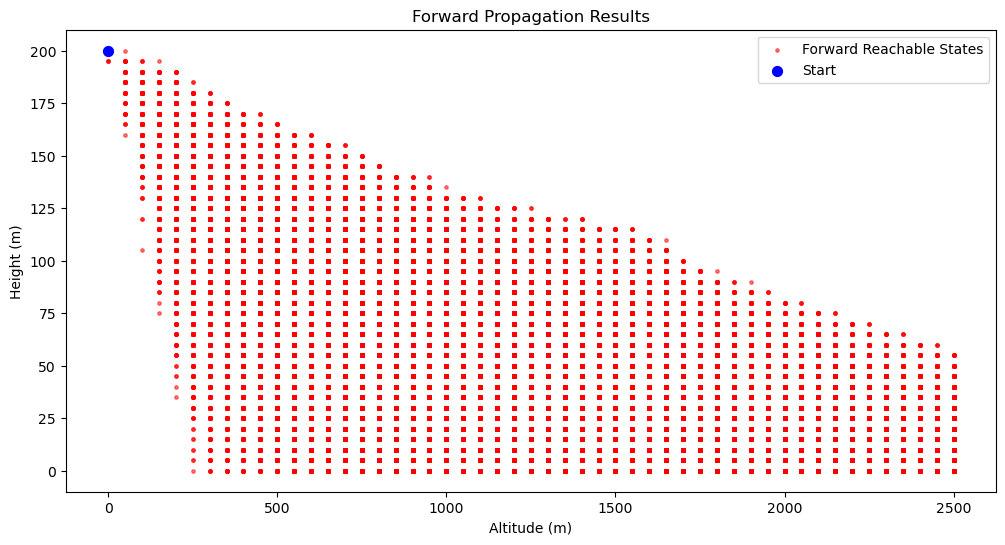

In [7]:
# Visualization of Forward Propagation
frs_Z = np.array([Z_GRID[idx[0]] for idx in frs])
frs_H = np.array([H_GRID[idx[1]] for idx in frs])

fig, ax = plt.subplots(figsize=(12,6))
ax.scatter(frs_Z, frs_H, c='red', alpha=0.5, s=6, label='Forward Reachable States')
ax.scatter([Z_SW], [H_SW], c='blue', s=50, label='Start')
ax.set_xlabel('Altitude (m)')
ax.set_ylabel('Height (m)')
ax.set_title('Forward Propagation Results')
ax.legend()
plt.show()

In [8]:
def eom_backward(v, gamma, CL):
    """Time-reversed EOM: all derivatives negated relative to eom()."""
    L = 0.5*RHO*v**2*S*CL
    D = 0.5*RHO*v**2*S*CD
    dz   = -v*np.cos(gamma)
    dh   = -v*np.sin(gamma)          # positive: sin(gamma) < 0 for glide angles
    dv   =  G*np.sin(gamma) + D/M
    dgam =  G*np.cos(gamma)/v - L/(M*v)
    return dz, dh, dv, dgam

def rk4_backward(z, h, v, gamma, CL, dt):
    k1 = eom_backward(v, gamma, CL)
    k1z, k1h, k1v, k1g = k1

    v2 = v + k1v*dt/2;  g2 = gamma + k1g*dt/2
    k2 = eom_backward(v2, g2, CL)

    v3 = v + k2[2]*dt/2;  g3 = gamma + k2[3]*dt/2
    k3 = eom_backward(v3, g3, CL)

    v4 = v + k3[2]*dt;  g4 = gamma + k3[3]*dt
    k4 = eom_backward(v4, g4, CL)

    zn = z     + dt/6*(k1z  + 2*k2[0] + 2*k3[0] + k4[0])
    hn = h     + dt/6*(k1h  + 2*k2[1] + 2*k3[1] + k4[1])
    vn = v     + dt/6*(k1v  + 2*k2[2] + 2*k3[2] + k4[2])
    gn = gamma + dt/6*(k1g  + 2*k2[3] + 2*k3[3] + k4[3])
    return zn, hn, vn, gn

def optimal_glide_time():
    """
    Compute t_goal_min: time for a straight-line equilibrium glide
    from (Z_SW, H_SW) to (Z_GOAL, H_GOAL) at the geometric glide angle.

    At this angle, CL is solved from tan(|gamma|) = CD/CL (steady glide),
    and v_eq from L = W*cos(gamma).
    """
    delta_z = Z_GOAL - Z_SW
    delta_h = H_GOAL - H_SW          # negative (descending)
    gamma_geom = np.arctan2(delta_h, delta_z)

    # Steady-glide equilibrium: tan(|gamma|) = CD / CL
    CL_eq = np.clip(CD / np.tan(np.abs(gamma_geom)), CL_MIN, CL_MAX)

    # Lift = Weight * cos(gamma)  =>  solve for v
    v_eq = np.sqrt(2*M*G*np.cos(np.abs(gamma_geom)) / (RHO * S * CL_eq))
    v_eq = np.clip(v_eq, V_STALL, V_MAX)

    t_min = delta_z / (v_eq * np.cos(np.abs(gamma_geom)))

    print(f'  gamma_geom : {np.degrees(gamma_geom):.2f} deg')
    print(f'  CL_eq      : {CL_eq:.3f}')
    print(f'  v_eq       : {v_eq:.2f} m/s')
    print(f'  t_goal_min : {t_min:.1f} s')
    return t_min

In [9]:
def backward_propagation(t_goal):
    """
    Propagate reachable set backward in time from (Z_GOAL, H_GOAL) for t_goal seconds.

    Level-by-level BFS: each level = one DT timestep backward.
    Returns the set of grid indices reachable at t=0 that can reach the goal at t=t_goal.
    """
    n_steps = round(t_goal / DT)

    visited = set()
    frontier = []

    # Initialize: all valid (v, gamma) grid combinations at (Z_GOAL, H_GOAL)
    iz_goal = round((Z_GOAL - Z_GRID[0]) / DZ)
    ih_goal = round((H_GOAL - H_GRID[0]) / DH)
    for iv in range(NV):
        for ig in range(NG):
            idx = (iz_goal, ih_goal, iv, ig)
            visited.add(idx)
            frontier.append((Z_GOAL, H_GOAL, V_GRID[iv], GAM_GRID[ig]))

    print(f'Backward propagation: t_goal={t_goal:.1f}s, n_steps={n_steps}, init_states={len(frontier)}')

    for step in range(n_steps):
        next_frontier = []
        for z, h, v, gamma in frontier:
            for CL in CL_DISCRETE:
                zn, hn, vn, gn = rk4_backward(z, h, v, gamma, CL, DT)

                if hn < H_GOAL or hn > H_SW:
                    continue
                if zn < Z_SW or zn > Z_GOAL:
                    continue
                if vn < V_STALL:
                    continue

                idxn = snap(zn, hn, vn, gn)
                if idxn is None:
                    continue
                if idxn in visited:
                    continue

                visited.add(idxn)
                next_frontier.append((zn, hn, vn, gn))

        frontier = next_frontier
        if not frontier:
            print(f'  Converged early at step {step+1}/{n_steps}')
            break

    print(f'  Done. Reachable backward states: {len(visited)}')
    return visited

In [10]:
T_GOAL_BUFFER = 60.0   # seconds of extra time beyond optimal glide

print('Computing t_goal range...')
t_goal_min = optimal_glide_time()
t_goal_max = t_goal_min + T_GOAL_BUFFER
print(f'  t_goal_max : {t_goal_max:.1f} s')

print('\nRunning Backward Propagation at t_goal = t_goal_min...')
start_time = time.time()
brs = backward_propagation(t_goal_min)
end_time = time.time()
print(f'Time taken: {end_time - start_time:.1f} s')

Computing t_goal range...
  gamma_geom : -4.57 deg
  CL_eq      : 0.312
  v_eq       : 27.68 m/s
  t_goal_min : 90.6 s
  t_goal_max : 150.6 s

Running Backward Propagation at t_goal = t_goal_min...
Backward propagation: t_goal=90.6s, n_steps=91, init_states=4002
  Done. Reachable backward states: 953032
Time taken: 110.3 s


/tmp/ipykernel_691778/178673230.py:14: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/jeff/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


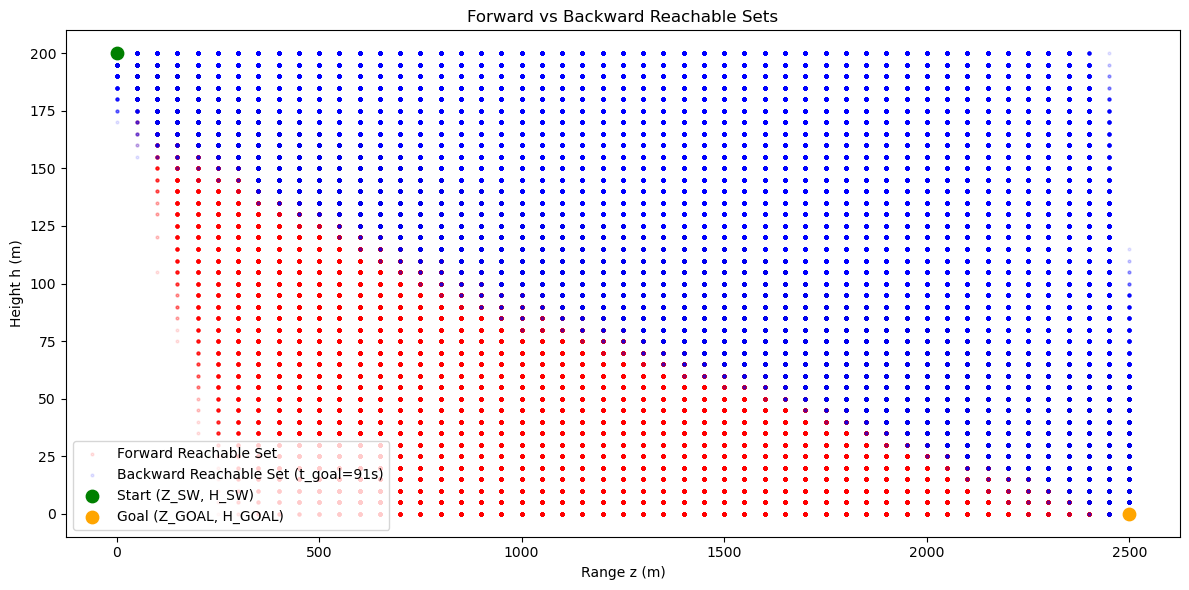

In [11]:
# Visualization
brs_Z = np.array([Z_GRID[idx[0]] for idx in brs])
brs_H = np.array([H_GRID[idx[1]] for idx in brs])

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(frs_Z, frs_H, c='red',  alpha=0.1, s=4, label='Forward Reachable Set')
ax.scatter(brs_Z, brs_H, c='blue', alpha=0.1, s=4, label=f'Backward Reachable Set (t_goal={t_goal_min:.0f}s)')
ax.scatter([Z_SW],   [H_SW],   c='green',  s=80, zorder=5, label='Start (Z_SW, H_SW)')
ax.scatter([Z_GOAL], [H_GOAL], c='orange', s=80, zorder=5, label='Goal (Z_GOAL, H_GOAL)')
ax.set_xlabel('Range z (m)')
ax.set_ylabel('Height h (m)')
ax.set_title('Forward vs Backward Reachable Sets')
ax.legend()
plt.tight_layout()
plt.show()

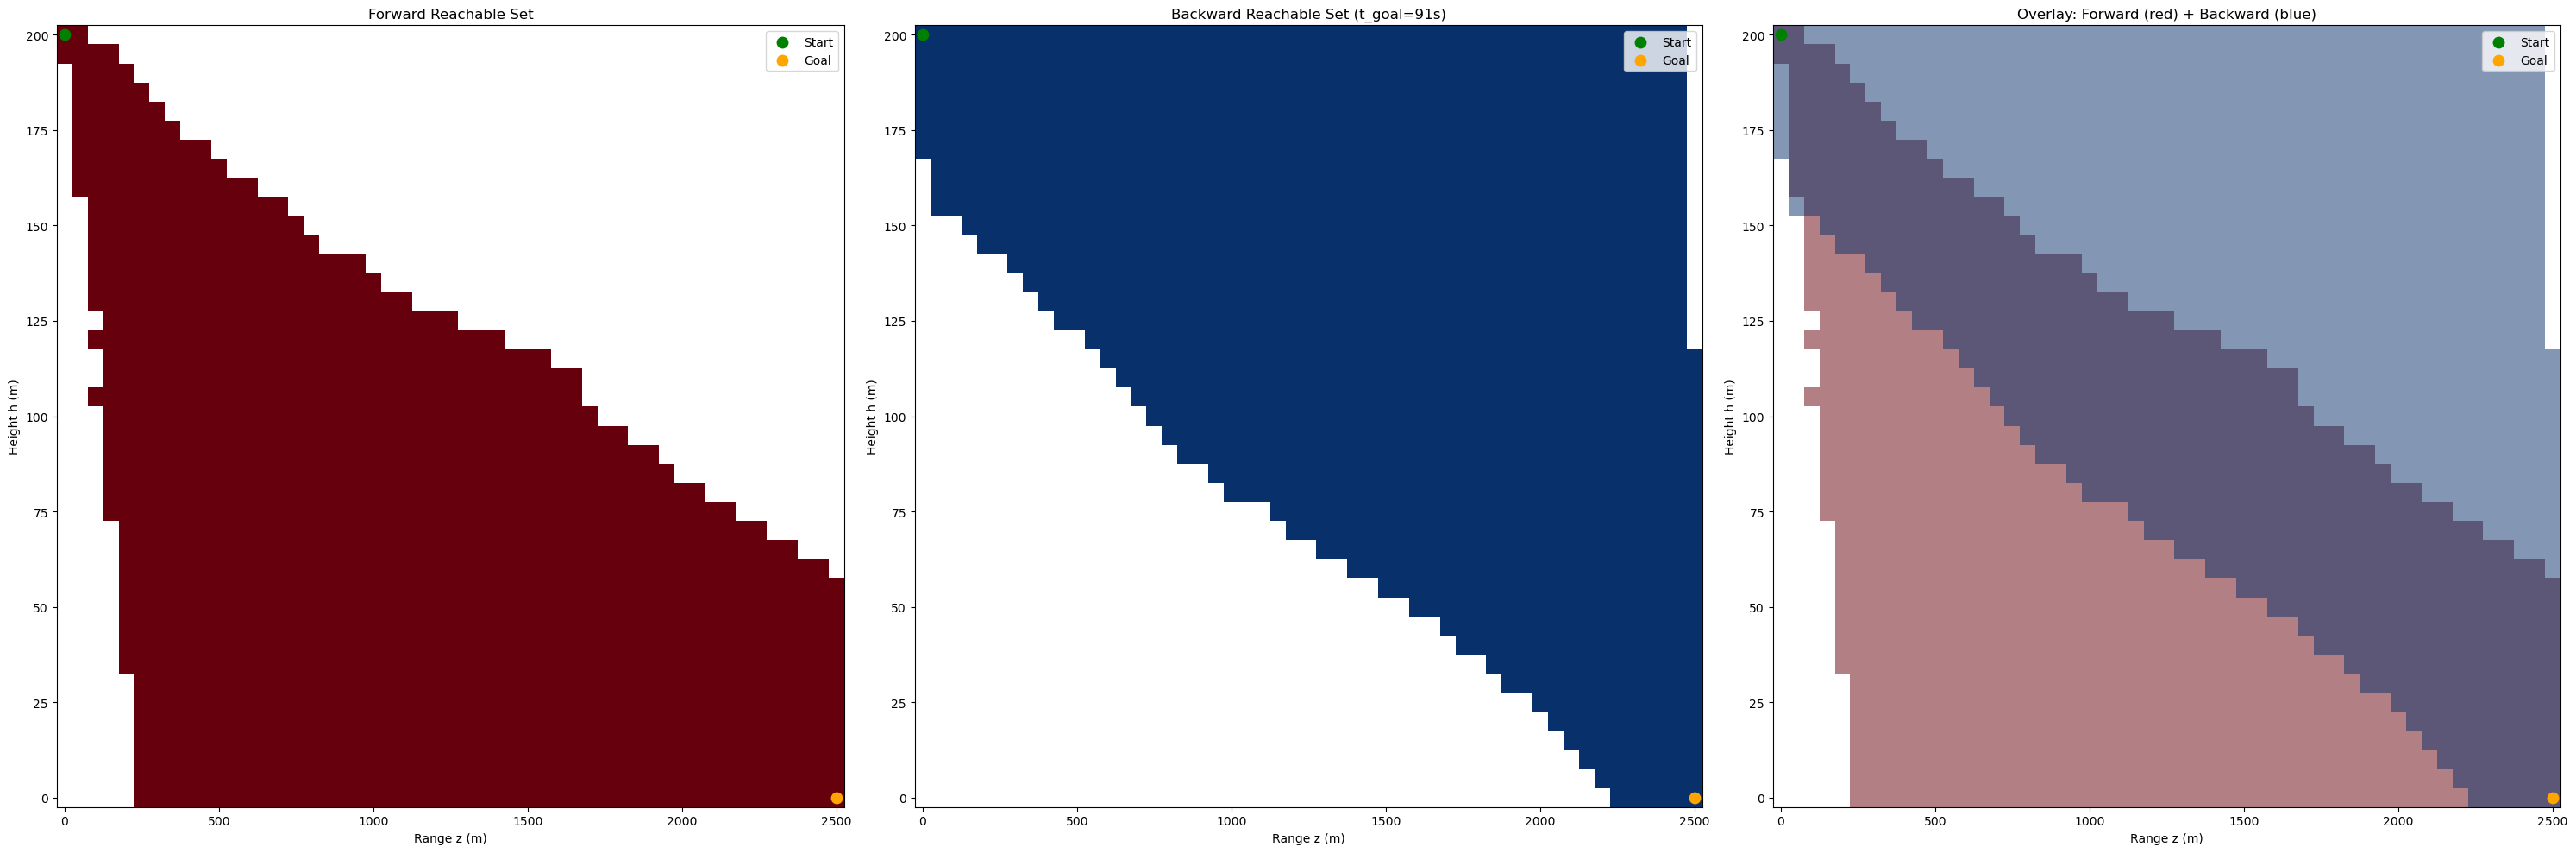

In [12]:
# --- Grid visualization ---
# Project 4D reachable sets onto Z-H plane (any v, gamma counts)
frs_grid = np.zeros((NZ, NH), dtype=bool)
for idx in frs:
    frs_grid[idx[0], idx[1]] = True

brs_grid = np.zeros((NZ, NH), dtype=bool)
for idx in brs:
    brs_grid[idx[0], idx[1]] = True

fig, axes = plt.subplots(1, 3, figsize=(30, 10))

def plot_grid(ax, grid, title, cmap):
    # Mask out empty cells so they render transparent
    masked = np.ma.masked_where(~grid.T, np.ones_like(grid.T, dtype=float))
    ax.pcolormesh(Z_GRID, H_GRID, masked, cmap=cmap, vmin=0, vmax=1)
    ax.scatter([Z_SW],   [H_SW],   c='green',  s=80, zorder=5, label='Start')
    ax.scatter([Z_GOAL], [H_GOAL], c='orange', s=80, zorder=5, label='Goal')
    ax.set_xlabel('Range z (m)')
    ax.set_ylabel('Height h (m)')
    ax.set_title(title)
    ax.legend()

plot_grid(axes[0], frs_grid, 'Forward Reachable Set', 'Reds')
plot_grid(axes[1], brs_grid, f'Backward Reachable Set (t_goal={t_goal_min:.0f}s)', 'Blues')

# Overlay
frs_m = np.ma.masked_where(~frs_grid.T, np.ones_like(frs_grid.T, dtype=float))
brs_m = np.ma.masked_where(~brs_grid.T, np.ones_like(brs_grid.T, dtype=float))
axes[2].pcolormesh(Z_GRID, H_GRID, frs_m, cmap='Reds',  alpha=0.5, vmin=0, vmax=1)
axes[2].pcolormesh(Z_GRID, H_GRID, brs_m, cmap='Blues', alpha=0.5, vmin=0, vmax=1)
axes[2].scatter([Z_SW],   [H_SW],   c='green',  s=80, zorder=5, label='Start')
axes[2].scatter([Z_GOAL], [H_GOAL], c='orange', s=80, zorder=5, label='Goal')
axes[2].set_xlabel('Range z (m)')
axes[2].set_ylabel('Height h (m)')
axes[2].set_title('Overlay: Forward (red) + Backward (blue)')
axes[2].legend()

plt.tight_layout()
plt.show()

Forward reachable  :   143492 states
Backward reachable :   953032 states
Feasible (both)    :    14199 states


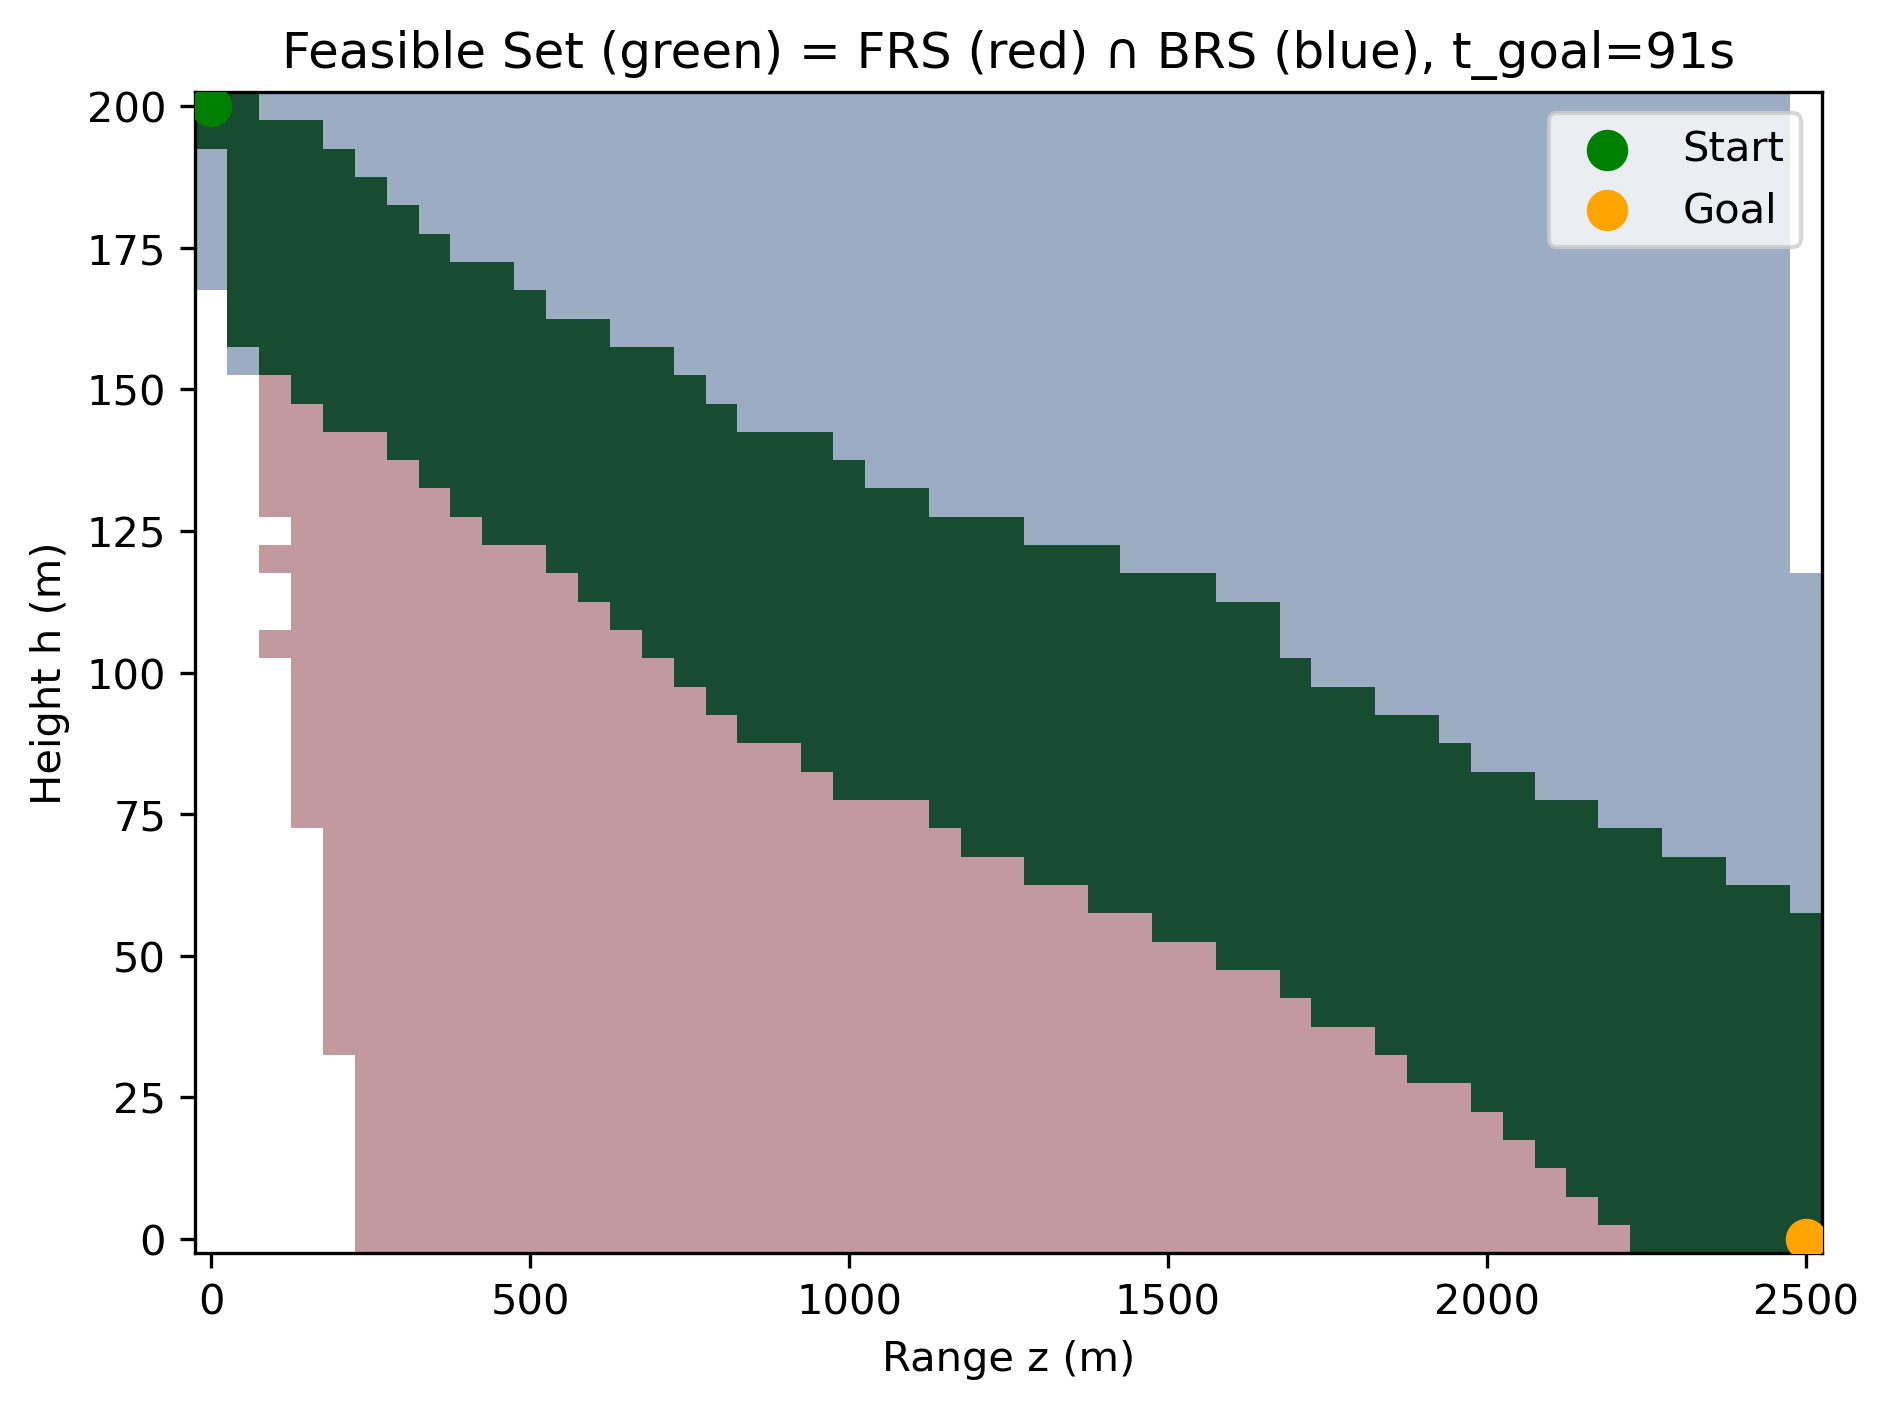

In [13]:
def feasible_set(frs, brs):
    """
    Returns all 4D grid states (iz, ih, iv, ig) that are in both
    the forward reachable set and the backward reachable set.
    """
    fs = frs & brs
    print(f'Forward reachable  : {len(frs):>8} states')
    print(f'Backward reachable : {len(brs):>8} states')
    print(f'Feasible (both)    : {len(fs):>8} states')
    return fs

fs = feasible_set(frs, brs)

# Project each set onto Z-H plane.
# frs_grid and brs_grid come from the cells above.
# fs_grid uses 2D AND so it exactly matches the visual overlap region.
frs_grid = np.zeros((NZ, NH), dtype=bool)
for idx in frs:
    frs_grid[idx[0], idx[1]] = True

brs_grid = np.zeros((NZ, NH), dtype=bool)
for idx in brs:
    brs_grid[idx[0], idx[1]] = True

fs_grid = frs_grid & brs_grid

fig, ax = plt.subplots(dpi=300)
frs_m = np.ma.masked_where(~frs_grid.T, np.ones_like(frs_grid.T, dtype=float))
brs_m = np.ma.masked_where(~brs_grid.T, np.ones_like(brs_grid.T, dtype=float))
fs_m  = np.ma.masked_where(~fs_grid.T,  np.ones_like(fs_grid.T,  dtype=float))
ax.pcolormesh(Z_GRID, H_GRID, frs_m, cmap='Reds',   alpha=0.4, vmin=0, vmax=1)
ax.pcolormesh(Z_GRID, H_GRID, brs_m, cmap='Blues',  alpha=0.4, vmin=0, vmax=1)
ax.pcolormesh(Z_GRID, H_GRID, fs_m,  cmap='Greens', alpha=0.8, vmin=0, vmax=1)
ax.scatter([Z_SW],   [H_SW],   c='green',  s=80, zorder=5, label='Start')
ax.scatter([Z_GOAL], [H_GOAL], c='orange', s=80, zorder=5, label='Goal')
ax.set_xlabel('Range z (m)')
ax.set_ylabel('Height h (m)')
ax.set_title(f'Feasible Set (green) = FRS (red) ∩ BRS (blue), t_goal={t_goal_min:.0f}s')
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# Diagnose: which set is missing s_start?
s_start = snap(Z_SW, H_SW, V_SW, GAM_SW)
print(f's_start grid index : {s_start}')
print(f's_start in frs     : {s_start in frs}')
print(f's_start in brs     : {s_start in brs}')
print(f's_start in fs      : {s_start in fs}')

# Estimate how many steps s_start actually needs to reach goal
v_horiz = V_SW * np.cos(np.abs(GAM_SW))
steps_needed = (Z_GOAL - Z_SW) / v_horiz
print(f'\nAt V_SW={V_SW} m/s, GAM_SW={np.degrees(GAM_SW):.1f} deg:')
print(f'  horizontal speed : {v_horiz:.2f} m/s')
print(f'  steps to goal    : {steps_needed:.1f}  (t_goal_min = {t_goal_min:.1f}s, t_goal_max = {t_goal_max:.1f}s)')

# Fix: rerun backward propagation with t_goal_max so s_start is included
print(f'\nRerunning backward propagation with t_goal_max = {t_goal_max:.1f}s ...')
start_time = time.time()
brs = backward_propagation(t_goal_max)
end_time = time.time()
print(f'Time taken: {end_time - start_time:.1f} s')

fs  = feasible_set(frs, brs)

# Recompute grids for visualization
frs_grid = np.zeros((NZ, NH), dtype=bool)
for idx in frs: frs_grid[idx[0], idx[1]] = True
brs_grid = np.zeros((NZ, NH), dtype=bool)
for idx in brs: brs_grid[idx[0], idx[1]] = True
fs_grid = frs_grid & brs_grid

print(f'\ns_start in brs (after fix) : {s_start in brs}')
print(f's_start in fs  (after fix) : {s_start in fs}')

s_start grid index : (0, 40, 8, 42)
s_start in frs     : True
s_start in brs     : False
s_start in fs      : False

At V_SW=22.0 m/s, GAM_SW=-5.0 deg:
  horizontal speed : 21.92 m/s
  steps to goal    : 114.1  (t_goal_min = 90.6s, t_goal_max = 150.6s)

Rerunning backward propagation with t_goal_max = 150.6s ...
Backward propagation: t_goal=150.6s, n_steps=151, init_states=4002
  Converged early at step 108/151
  Done. Reachable backward states: 957956
Time taken: 113.2 s
Forward reachable  :   143492 states
Backward reachable :   957956 states
Feasible (both)    :    14225 states

s_start in brs (after fix) : False
s_start in fs  (after fix) : False


In [15]:
import heapq

# ── Modular cost function ─────────────────────────────────────────────────────
def step_cost(v, gamma, CL, dt):
    """Energy dissipated per step: drag power × dt. Swap to change objective."""
    D = 0.5 * RHO * v**2 * S * CD
    return D * v * dt

# ── Value function via forward Dijkstra ───────────────────────────────────────
def bellman_optimal(frs, cost_fn=step_cost):
    """
    Forward Dijkstra from s_start, expanding via forward dynamics within frs.

    Stores continuous (z,h,v,gamma) per grid cell to avoid grid drift —
    same technique as forward_propagation. Without this, the first step from
    s_start snaps back to s_start (dz~22m < DZ=50m) and expansion stalls.

    V[s]          = min energy cost to reach s from start.
    prev_state[s] = previous grid state on the optimal path to s.
    """
    s_start = snap(Z_SW, H_SW, V_SW, GAM_SW)
    if s_start is None or s_start not in frs:
        raise RuntimeError('Start state not in frs!')

    V          = {s_start: 0.0}
    prev_state = {}
    cont       = {s_start: (Z_SW, H_SW, V_SW, GAM_SW)}
    heap       = [(0.0, 0, s_start)]
    counter    = 1

    while heap:
        cost, _, s = heapq.heappop(heap)
        if cost > V.get(s, float('inf')) + 1e-9:
            continue

        z, h, v, gamma = cont[s]          # continuous state, not grid centre

        for CL in CL_DISCRETE:
            zn, hn, vn, gn = rk4_forward(z, h, v, gamma, CL, DT)

            if hn < H_GOAL or hn > H_SW:   continue
            if zn < Z_SW   or zn > Z_GOAL: continue
            if vn < V_STALL:               continue

            s_next = snap(zn, hn, vn, gn)
            if s_next is None or s_next not in frs: continue

            g_cost   = cost_fn(v, gamma, CL, DT)
            new_cost = cost + g_cost

            if new_cost < V.get(s_next, float('inf')):
                V[s_next]          = new_cost
                prev_state[s_next] = s
                cont[s_next]       = (zn, hn, vn, gn)
                heapq.heappush(heap, (new_cost, counter, s_next))
                counter += 1

    iz_goal = round((Z_GOAL - Z_GRID[0]) / DZ)
    ih_goal = round((H_GOAL - H_GRID[0]) / DH)
    goal_costs = [V[s] for iv in range(NV) for ig in range(NG)
                  if (s := (iz_goal, ih_goal, iv, ig)) in V]
    if goal_costs:
        print(f'Optimal energy : {min(goal_costs):.2f} J')
    else:
        print('WARNING: no goal state reached.')
    print(f'Value function : {len(V)} states covered.')
    return V, prev_state

In [16]:
def extract_trajectory(V, prev_state):
    """
    Backward extraction via prev_state pointers: start at the cheapest goal
    state, follow prev_state back to s_start.

    Returns traj_idx  - list of grid tuples, goal → start
            traj_cont - list of (z, h, v, gamma), goal → start
    Reverse either list for the forward trajectory.
    """
    iz_goal = round((Z_GOAL - Z_GRID[0]) / DZ)
    ih_goal = round((H_GOAL - H_GRID[0]) / DH)
    s_start = snap(Z_SW, H_SW, V_SW, GAM_SW)

    # Find cheapest goal state reached by the forward Dijkstra
    best_goal, best_V = None, float('inf')
    for iv in range(NV):
        for ig in range(NG):
            s = (iz_goal, ih_goal, iv, ig)
            if s in V and V[s] < best_V:
                best_V, best_goal = V[s], s

    if best_goal is None:
        raise RuntimeError('No goal state reachable from start.')

    # Follow prev_state pointers backward: goal → start
    traj_idx = []
    s = best_goal
    while True:
        traj_idx.append(s)
        if s == s_start or s not in prev_state:
            break
        s = prev_state[s]

    traj_cont = [(Z_GRID[iz], H_GRID[ih], V_GRID[iv], GAM_GRID[ig])
                 for iz, ih, iv, ig in traj_idx]

    status = 'reached start' if traj_idx[-1] == s_start else \
             f'ended at z={Z_GRID[traj_idx[-1][0]]:.0f}, h={H_GRID[traj_idx[-1][1]]:.0f}'
    print(f'Extraction: {len(traj_cont)} steps, {status}. Total energy: {best_V:.2f} J')
    return traj_idx, traj_cont

In [17]:
print('Running Bellman DP...')
start_time = time.time()
V, prev_state = bellman_optimal(frs)
end_time = time.time()
print(f'Time taken: {end_time - start_time:.1f} s')

print('\nExtracting trajectory...')
traj_idx, traj_cont = extract_trajectory(V, prev_state)

# Forward trajectory: reverse the goal→start extraction
fwd_cont = list(reversed(traj_cont))
traj_z   = [s[0] for s in fwd_cont]
traj_h   = [s[1] for s in fwd_cont]
traj_v   = [s[2] for s in fwd_cont]
traj_gam = [np.degrees(s[3]) for s in fwd_cont]

Running Bellman DP...
Optimal energy : 2701.58 J
Value function : 49219 states covered.
Time taken: 6.7 s

Extracting trajectory...
Extraction: 95 steps, reached start. Total energy: 2701.58 J


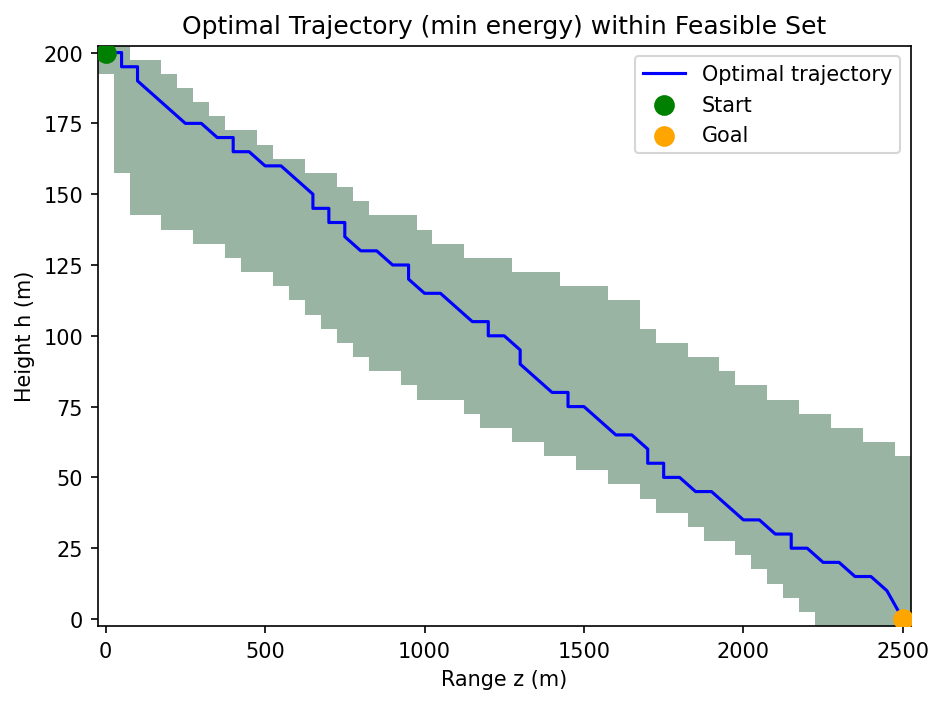

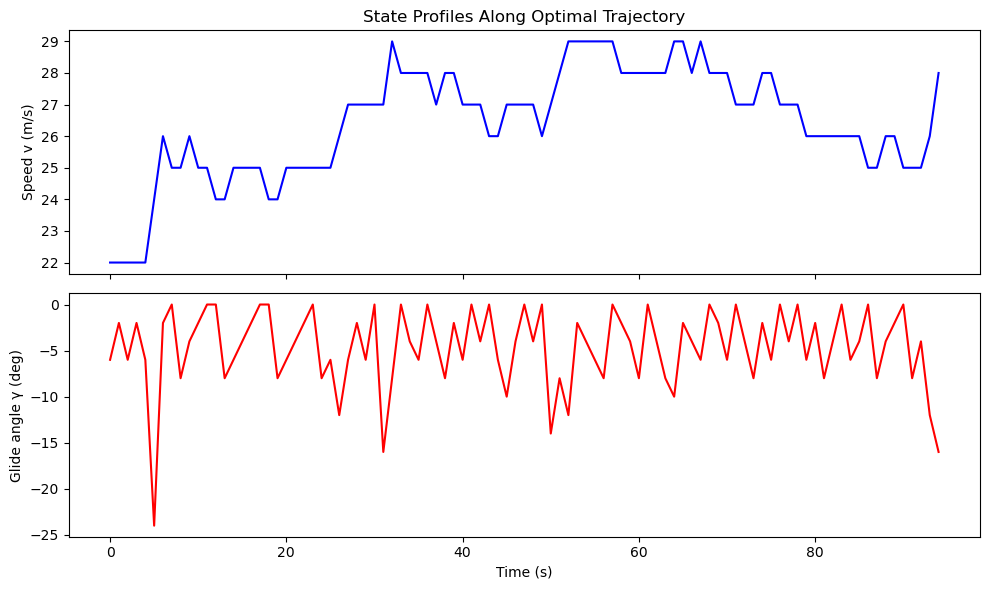

In [18]:
# ── Plot 1: trajectory on Z-H plane overlaid with feasible set ───────────────
fig, ax = plt.subplots(dpi=150)
fs_m = np.ma.masked_where(~fs_grid.T, np.ones_like(fs_grid.T, dtype=float))
ax.pcolormesh(Z_GRID, H_GRID, fs_m, cmap='Greens', alpha=0.4, vmin=0, vmax=1)
ax.plot(traj_z, traj_h, 'b-', linewidth=1.5, label='Optimal trajectory')
ax.scatter([traj_z[0]],  [traj_h[0]],  c='green',  s=80, zorder=5, label='Start')
ax.scatter([traj_z[-1]], [traj_h[-1]], c='orange', s=80, zorder=5, label='Goal')
ax.set_xlabel('Range z (m)')
ax.set_ylabel('Height h (m)')
ax.set_title('Optimal Trajectory (min energy) within Feasible Set')
ax.legend()
plt.tight_layout()
plt.show()

# ── Plot 2: state profiles along trajectory ───────────────────────────────────
t_axis = np.arange(len(fwd_cont)) * DT
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(t_axis, traj_v,   'b')
axes[0].set_ylabel('Speed v (m/s)')
axes[0].set_title('State Profiles Along Optimal Trajectory')
axes[1].plot(t_axis, traj_gam, 'r')
axes[1].set_ylabel('Glide angle γ (deg)')
axes[1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()